<a href="https://colab.research.google.com/github/MOHDVAZI4/college_labsheet_computervision/blob/main/labsheet.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os
import time

from pathlib import Path
from google.colab import files
from skimage.feature import hog
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

print("Libraries imported successfully!")

Libraries imported successfully!


Saving Screenshot 2026-10-09 231748.png to Screenshot 2026-10-09 231748.png
Total SIFT keypoints: 222


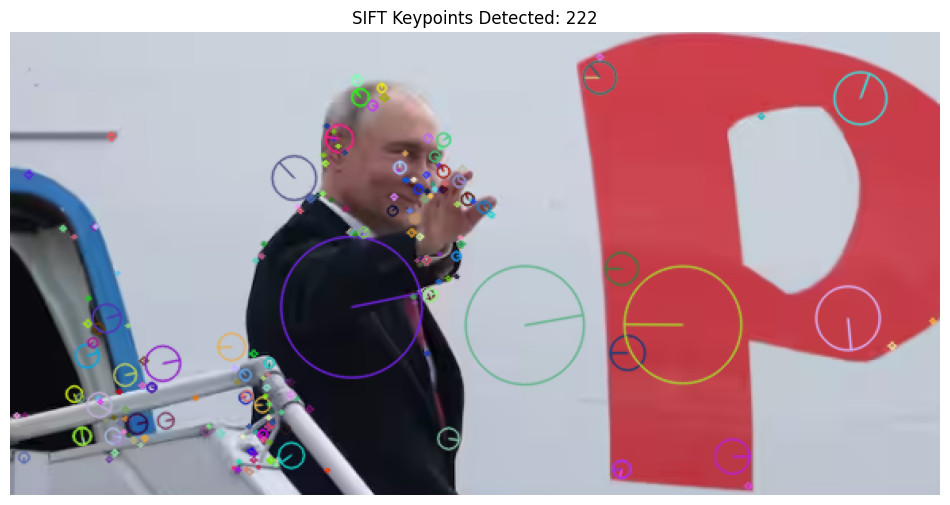

In [2]:
uploaded = files.upload()
image_path = next(iter(uploaded))

image = cv2.imread(image_path)

if image is None:
    raise ValueError("Could not load image.")

gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

sift = cv2.SIFT_create()
keypoints, descriptors = sift.detectAndCompute(gray, None)

output = cv2.drawKeypoints(
    image,
    keypoints,
    None,
    flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS
)

print("Total SIFT keypoints:", len(keypoints))

plt.figure(figsize=(12, 8))
plt.imshow(cv2.cvtColor(output, cv2.COLOR_BGR2RGB))
plt.title(f"SIFT Keypoints Detected: {len(keypoints)}")
plt.axis("off")
plt.show()

Saving Screenshot 2026-10-09 231748.png to Screenshot 2026-10-09 231748 (4).png
Good matches: 96
RANSAC inliers: 92


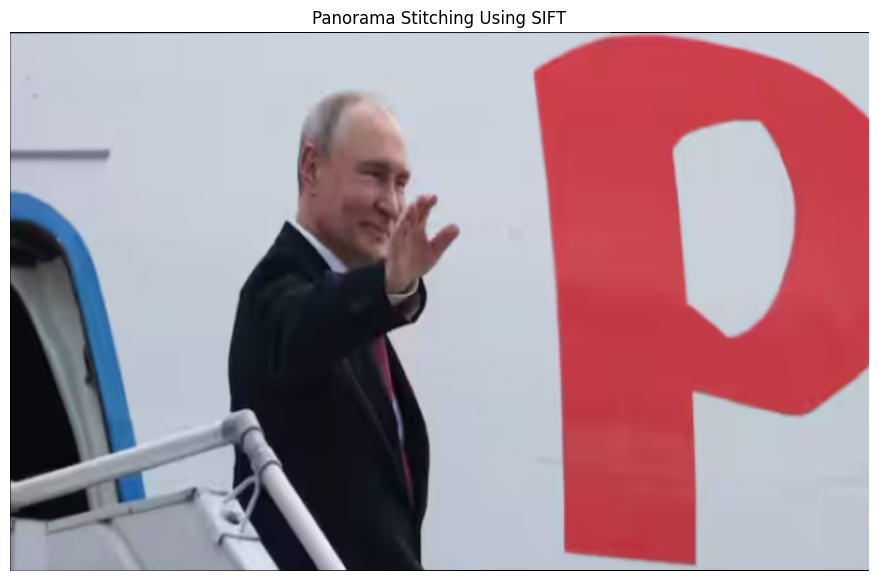

In [6]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

# Upload only ONE image
uploaded = files.upload()
image_path = next(iter(uploaded))

image = cv2.imread(image_path)

if image is None:
    raise ValueError("Could not load the image.")

# Resize image for easier processing
image = cv2.resize(image, (800, 500))

# Create two overlapping views from the same image
h, w = image.shape[:2]

left = image[:, :int(w * 0.7)]
right = image[:, int(w * 0.3):]

# Convert to grayscale
gray_left = cv2.cvtColor(left, cv2.COLOR_BGR2GRAY)
gray_right = cv2.cvtColor(right, cv2.COLOR_BGR2GRAY)

# Detect SIFT features
sift = cv2.SIFT_create()

kp1, des1 = sift.detectAndCompute(gray_left, None)
kp2, des2 = sift.detectAndCompute(gray_right, None)

if des1 is None or des2 is None:
    raise ValueError("Not enough SIFT features. Try a more detailed image.")

# Match descriptors
bf = cv2.BFMatcher()
matches = bf.knnMatch(des1, des2, k=2)

good_matches = [
    m for m, n in matches
    if m.distance < 0.75 * n.distance
]

print("Good matches:", len(good_matches))

if len(good_matches) < 4:
    raise ValueError("Not enough matches to stitch the image.")

# Find matching points
src_pts = np.float32([
    kp1[m.queryIdx].pt for m in good_matches
]).reshape(-1, 1, 2)

dst_pts = np.float32([
    kp2[m.trainIdx].pt for m in good_matches
]).reshape(-1, 1, 2)

# Estimate homography
H, mask = cv2.findHomography(
    src_pts, dst_pts, cv2.RANSAC, 5.0
)

if H is None:
    raise ValueError("Homography estimation failed.")

# Warp the left image into the right image's coordinate system
h1, w1 = left.shape[:2]
h2, w2 = right.shape[:2]

corners = np.float32([
    [0, 0], [w1, 0], [w1, h1], [0, h1]
]).reshape(-1, 1, 2)

warped_corners = cv2.perspectiveTransform(corners, H)

right_corners = np.float32([
    [0, 0], [w2, 0], [w2, h2], [0, h2]
]).reshape(-1, 1, 2)

all_corners = np.concatenate(
    (warped_corners, right_corners), axis=0
)

xmin, ymin = np.floor(
    all_corners.min(axis=0).ravel()
).astype(int)

xmax, ymax = np.ceil(
    all_corners.max(axis=0).ravel()
).astype(int)

translation = np.array([
    [1, 0, -xmin],
    [0, 1, -ymin],
    [0, 0, 1]
], dtype=np.float64)

panorama = cv2.warpPerspective(
    left,
    translation @ H,
    (xmax - xmin, ymax - ymin)
)

# Place the right image on the canvas
x_offset = -xmin
y_offset = -ymin

panorama[
    y_offset:y_offset + h2,
    x_offset:x_offset + w2
] = right

# Display result
print("RANSAC inliers:", int(mask.sum()))

plt.figure(figsize=(14, 7))
plt.imshow(cv2.cvtColor(panorama, cv2.COLOR_BGR2RGB))
plt.title("Panorama Stitching Using SIFT")
plt.axis("off")
plt.show()

Saving Screenshot 2026-10-09 231748.png to Screenshot 2026-10-09 231748 (6).png
Original keypoints: 222
Scaled keypoints: 289
Rotated keypoints: 157
Original-to-scaled matches: 166
Original-to-rotated matches: 104


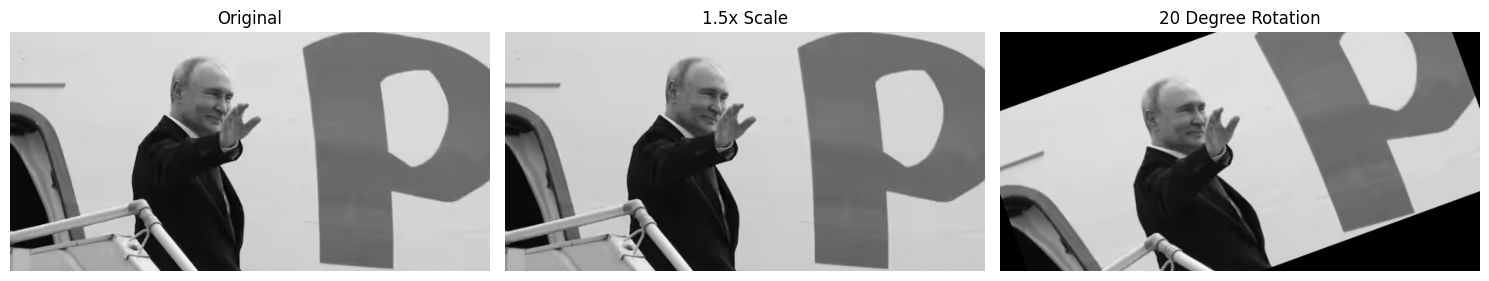

In [8]:
uploaded = files.upload()
filename = next(iter(uploaded))

image = cv2.imread(filename)

if image is None:
    raise ValueError("Could not load image.")

gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

scaled = cv2.resize(
    gray,
    None,
    fx=1.5,
    fy=1.5,
    interpolation=cv2.INTER_CUBIC
)

center = (gray.shape[1] // 2, gray.shape[0] // 2)

rotation_matrix = cv2.getRotationMatrix2D(center, 20, 1.0)

rotated = cv2.warpAffine(
    gray,
    rotation_matrix,
    (gray.shape[1], gray.shape[0])
)

sift = cv2.SIFT_create()

kp1, des1 = sift.detectAndCompute(gray, None)
kp2, des2 = sift.detectAndCompute(scaled, None)
kp3, des3 = sift.detectAndCompute(rotated, None)

bf = cv2.BFMatcher()

def good_match_count(desc1, desc2):
    if desc1 is None or desc2 is None:
        return 0

    matches = bf.knnMatch(desc1, desc2, k=2)

    return sum(
        1 for m, n in matches
        if m.distance < 0.75 * n.distance
    )

scale_matches = good_match_count(des1, des2)
rotation_matches = good_match_count(des1, des3)

print("Original keypoints:", len(kp1))
print("Scaled keypoints:", len(kp2))
print("Rotated keypoints:", len(kp3))
print("Original-to-scaled matches:", scale_matches)
print("Original-to-rotated matches:", rotation_matches)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(gray, cmap="gray")
axes[0].set_title("Original")

axes[1].imshow(scaled, cmap="gray")
axes[1].set_title("1.5x Scale")

axes[2].imshow(rotated, cmap="gray")
axes[2].set_title("20 Degree Rotation")

for ax in axes:
    ax.axis("off")

plt.tight_layout()
plt.show()

Saving Screenshot 2026-10-09 231748.png to Screenshot 2026-10-09 231748 (7).png


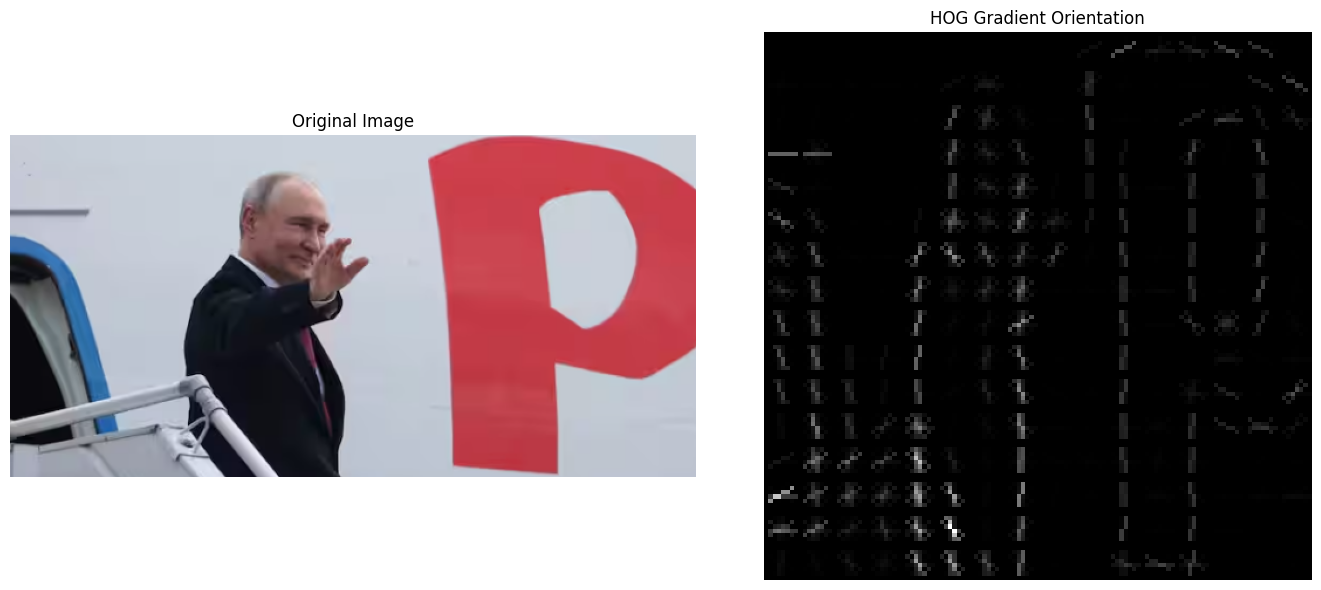

HOG feature vector length: 8100


In [9]:
uploaded = files.upload()
filename = next(iter(uploaded))

image = cv2.imread(filename)

if image is None:
    raise ValueError("Could not load image.")

gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
gray = cv2.resize(gray, (128, 128))

hog_features, hog_image = hog(
    gray,
    orientations=9,
    pixels_per_cell=(8, 8),
    cells_per_block=(2, 2),
    block_norm="L2-Hys",
    visualize=True,
    feature_vector=True
)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
axes[0].set_title("Original Image")
axes[0].axis("off")

axes[1].imshow(hog_image, cmap="gray")
axes[1].set_title("HOG Gradient Orientation")
axes[1].axis("off")

plt.tight_layout()
plt.show()

print("HOG feature vector length:", len(hog_features))

In [ ]:
uploaded = files.upload()

images = []

for filename in uploaded:
    img = cv2.imread(filename)
    if img is not None:
        images.append(img)

if len(images) < 2:
    raise ValueError("Upload two valid images together.")

image1, image2 = images[:2]

gray1 = cv2.cvtColor(image1, cv2.COLOR_BGR2GRAY)
gray2 = cv2.cvtColor(image2, cv2.COLOR_BGR2GRAY)

sift = cv2.SIFT_create()

kp1, des1 = sift.detectAndCompute(gray1, None)
kp2, des2 = sift.detectAndCompute(gray2, None)

if des1 is None or des2 is None:
    raise ValueError("Could not detect sufficient features.")

bf = cv2.BFMatcher()
matches = bf.knnMatch(des1, des2, k=2)

good_matches = [
    m for m, n in matches
    if m.distance < 0.75 * n.distance
]

output = cv2.drawMatches(
    image1, kp1,
    image2, kp2,
    good_matches[:80],
    None,
    flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS
)

print("Good matches:", len(good_matches))

plt.figure(figsize=(16, 8))
plt.imshow(cv2.cvtColor(output, cv2.COLOR_BGR2RGB))
plt.title("SIFT Image Matching")
plt.axis("off")
plt.show()